In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
tf.config.set_visible_devices(tf.config.list_physical_devices('GPU')[1], 'GPU')

import hmc_3hl as hmc

In [7]:
alphas_L = np.array([1+1/6, 1+2/6, 1+3/6, 1+4/6, 1+5/6, 2, 2+1/3, 2+2/3, 3, 3+1/3, 3+2/3, 4])
alphas_L*3

array([ 3.5,  4. ,  4.5,  5. ,  5.5,  6. ,  7. ,  8. ,  9. , 10. , 11. ,
       12. ])

In [18]:
d = 30
gamma_1 = 1
gamma_2 = 1
gamma_3 = 1
alpha = 4
Delta = 0.1
vlaw = 'ones'
k1 = int(gamma_1*d)
k2 = int(gamma_2*d)
k3 = int(gamma_3*d)



sig_1 = lambda x: (tf.nn.tanh(2*x)-0.729477*x)/0.321129
sig_2 = lambda x: (tf.nn.tanh(2*x)-0.729477*x)/0.321129
sig_3 = lambda x: (tf.nn.tanh(2*x)-0.729477*x)/0.321129

params = {'step_size': 0.01,
          'num_leapfrog_steps': 10,
          'num_adaptation_steps': 8000,
          }

ntest = 10000
Xtest = tf.random.normal((d, ntest), dtype=tf.float32)

In [19]:
W10, W20, W30, v, X, Y = hmc.data_generate(d, alpha, gamma_1, gamma_2, gamma_3, sig_1, sig_2, sig_3, Delta, vlaw)
W1s_info, W2s_info, W3s_info = hmc.hmc(params, W10, W20, W30, v, X, Y, Delta, sig_1, sig_2, sig_3, info=True)
test_info = hmc.test_error(W1s_info, W2s_info, W3s_info, W10, W20, W30, v, sig_1, sig_2, sig_3, Xtest)

### test errors

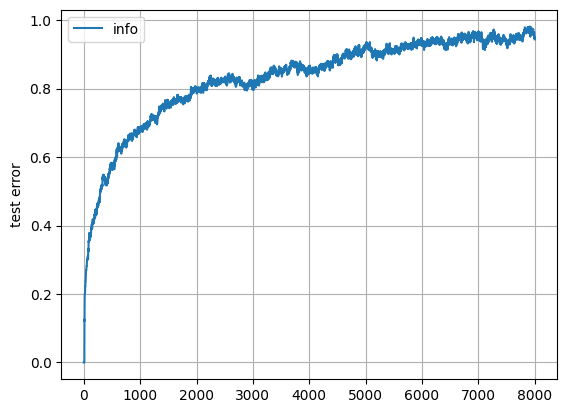

In [20]:
plt.plot(test_info, label='info')
plt.ylabel('test error')
plt.legend()
plt.grid()
# plt.ylim(0,0.05)
plt.show()